In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv(r"E:\Pyhton code\Data Sets\archive\mall segmentation dataset\Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [5]:
df['Gender'] = df['Gender'].str.strip().str.lower()
df['Gender'] = df['Gender'].map({'male': 0, 'female': 1})

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    int64
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB


In [7]:
df.describe()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,0.560000,38.850000,60.560000,50.200000
std,57.879185,0.497633,13.969007,26.264721,25.823522
min,1.000000,0.000000,18.000000,15.000000,1.000000
25%,50.750000,0.000000,28.750000,41.500000,34.750000
50%,100.500000,1.000000,36.000000,61.500000,50.000000
75%,150.250000,1.000000,49.000000,78.000000,73.000000
max,200.000000,1.000000,70.000000,137.000000,99.000000


In [8]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [9]:
#Drop unnecessary column
df = df.drop("CustomerID", axis=1)

In [10]:
#Feature selection
x = df[['Gender','Age','Annual Income (k$)', 'Spending Score (1-100)']]

In [11]:
#Feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

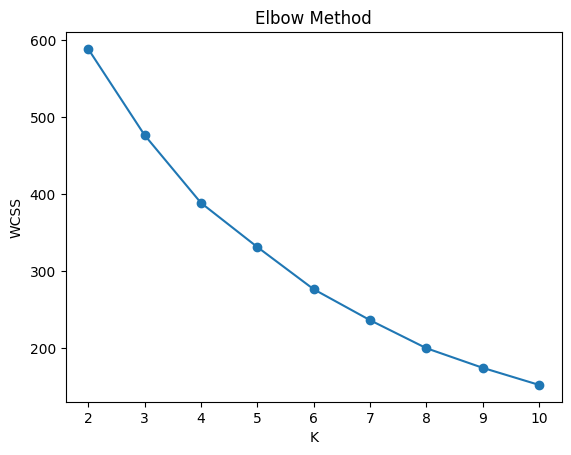

In [12]:
#Elbow method (find k)
from sklearn.cluster import KMeans
inertia = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)
    
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()    

In [13]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, labels)
    print(f"K={k}, Score={score}")

K=2, Score=0.25181529157884364
K=3, Score=0.25951265087431563
K=4, Score=0.2983972818544038
K=5, Score=0.3040600988258827
K=6, Score=0.33107393337175933
K=7, Score=0.3573771582429211
K=8, Score=0.3879927454351689
K=9, Score=0.4030916511655521
K=10, Score=0.42076374869477745


In [14]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
labels = kmeans.fit_predict(x_scaled)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=x.columns)
print(centroid_df)

     Gender        Age  Annual Income (k$)  Spending Score (1-100)
0  0.538462  32.692308           86.538462               82.128205
1  0.551724  36.482759           89.517241               18.000000
2  1.000000  49.813953           49.232558               40.069767
3  0.592593  24.907407           39.722222               61.203704
4  0.000000  55.714286           53.685714               36.771429


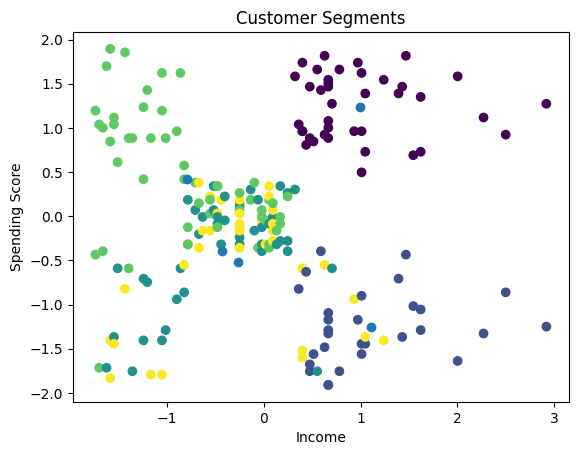

In [15]:
plt.scatter(x_scaled[:,2], x_scaled[:,3], c=labels)
plt.scatter(kmeans.cluster_centers_[:,2], kmeans.cluster_centers_[:,3])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

In [16]:
from sklearn.metrics import silhouette_score
score = silhouette_score(x_scaled, labels)
print("Silhouette Score:",score)

Silhouette Score: 0.3040600988258827


In [17]:
df['Cluster'] = labels

In [18]:
print(df.groupby('Cluster').mean())

           Gender        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                 
0        0.538462  32.692308           86.538462               82.128205
1        0.551724  36.482759           89.517241               18.000000
2        1.000000  49.813953           49.232558               40.069767
3        0.592593  24.907407           39.722222               61.203704
4        0.000000  55.714286           53.685714               36.771429


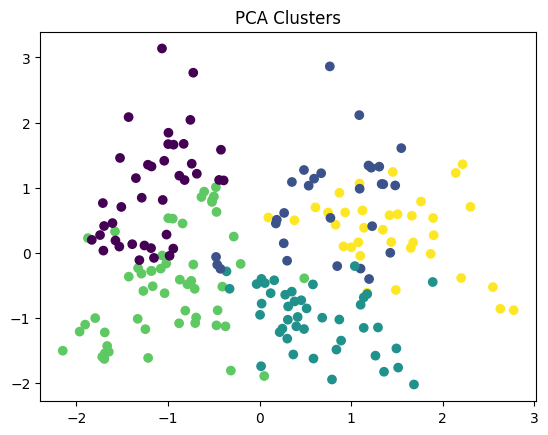

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.title("PCA Clusters")
plt.show()

In [20]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5)
db_labels = db.fit_predict(x_scaled)

print("Clusters:", set(db_labels))
print("Noise points:", list(db_labels).count(-1))

Clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(-1)}
Noise points: 105


In [21]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']